# 📊 Customer Churn Prediction

<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 50%, #0f172a 100%); border-radius: 16px; text-align: center; font-family: 'Segoe UI', sans-serif; padding: 28px;">

<h1 style="color: #60a5fa; font-size: 2.8em; margin-bottom: 10px; letter-spacing: 2px;">📡 Telecom Customer Churn Prediction</h1>
<h3 style="color: #94a3b8; font-weight: 400; margin-bottom: 30px; font-size: 1.3em;">End-to-End Machine Learning Pipeline · EDA · Feature Engineering · Ensemble Models · SHAP · Business Insights</h3>

<hr style="border-color: #334155; margin: 25px 0;">

<table style="margin: 0 auto; color: #cbd5e1; font-size: 1.05em; border-collapse: collapse;">
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">👤 Author</td><td style="padding: 6px 20px; text-align:left;">Muhammad Hanzla</td></tr>
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">📊 Dataset</td><td style="padding: 6px 20px; text-align:left;">IBM Telco Customer Churn (Kaggle)</td></tr>
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">🔗 Kaggle</td><td style="padding: 6px 20px; text-align:left;"><a href="https://www.kaggle.com/muhammadhanzla1234" style="color:#38bdf8;">kaggle.com/muhammadhanzla1234</a></td></tr>
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">💼 LinkedIn</td><td style="padding: 6px 20px; text-align:left;"><a href="https://www.linkedin.com/in/muhammad-hanzla-17a79237a/" style="color:#38bdf8;">linkedin.com/in/muhammad-hanzla</a></td></tr>
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">💻 GitHub</td><td style="padding: 6px 20px; text-align:left;"><a href="https://github.com/muhammadhanzlaaltaf" style="color:#38bdf8;">github.com/muhammadhanzlaaltaf</a></td></tr>
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">📷 Instagram</td><td style="padding: 6px 20px; text-align:left;"><a href="https://www.instagram.com/m.hanzlaaltaf/" style="color:#38bdf8;">@m.hanzlaaltaf</a></td></tr>
    <tr><td style="padding: 6px 20px; text-align:left; color:#60a5fa; font-weight:600;">📧 Email</td><td style="padding: 6px 20px; text-align:left;"><a href="mailto:muhammadhanzlaaltaf@gmail.com" style="color:#38bdf8;">muhammadhanzlaaltaf@gmail.com</a></td></tr>
</table>

<hr style="border-color: #334155; margin: 25px 0;">

<p style="color:#e2e8f0; font-size:1.05em; margin: 0 0 10px 0;"><strong>Goal:</strong> Predict which telecom customers will churn so the business can intervene early.</p>

<p style="color:#e2e8f0; font-size:1.05em; margin: 0;"><strong>Pipeline:</strong> <code>Load Data</code> → <code>EDA</code> → <code>Cleaning</code> → <code>Feature Engineering</code> → <code>SMOTE</code> → <code>Model Training</code> → <code>Evaluation</code> → <code>Flask API</code></p>

</div>


In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.metrics        import (classification_report, roc_auc_score,
                                    roc_curve, ConfusionMatrixDisplay,
                                    precision_recall_curve, average_precision_score)
from sklearn.ensemble       import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model   import LogisticRegression
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='Blues_d')
np.random.seed(42)
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## 1. Load Dataset
Using the official **Telco Customer Churn** dataset from Kaggle.

In [2]:
# ── Load the real Kaggle Telco dataset ───────────────────
PATH = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(PATH)
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Shape   : (7043, 21)
Columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Initial Exploration

In [3]:
print('=== Dataset Info ===')
print(df.info())
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Target Distribution ===')
print(df['Churn'].value_counts())
print(f"Churn rate : {(df['Churn']=='Yes').mean():.2%}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

## 3. Data Cleaning
- `TotalCharges` is stored as string — convert to numeric  
- Drop `customerID` (not a feature)  
- Handle empty strings in `TotalCharges`

In [4]:
# ── Cleaning ─────────────────────────────────────────────

# 1. Drop customer ID (not a feature)
df.drop('customerID', axis=1, inplace=True)

# 2. TotalCharges has spaces for new customers with 0 tenure — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'NaN in TotalCharges after conversion: {df["TotalCharges"].isna().sum()}')

# 3. Fill NaN TotalCharges with 0 (new customers, tenure=0)
df['TotalCharges'].fillna(0, inplace=True)

# 4. Encode binary target: Yes→1, No→0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 5. Fix SeniorCitizen — already 0/1 but confirm
print(f'SeniorCitizen values : {df["SeniorCitizen"].unique()}')

print(f'\nCleaned shape : {df.shape}')
print(f'Churn rate    : {df["Churn"].mean():.2%}')
df.head(3)

NaN in TotalCharges after conversion: 11
SeniorCitizen values : [0 1]

Cleaned shape : (7043, 20)
Churn rate    : 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## 4. Exploratory Data Analysis
### 4.1 Target & Demographics

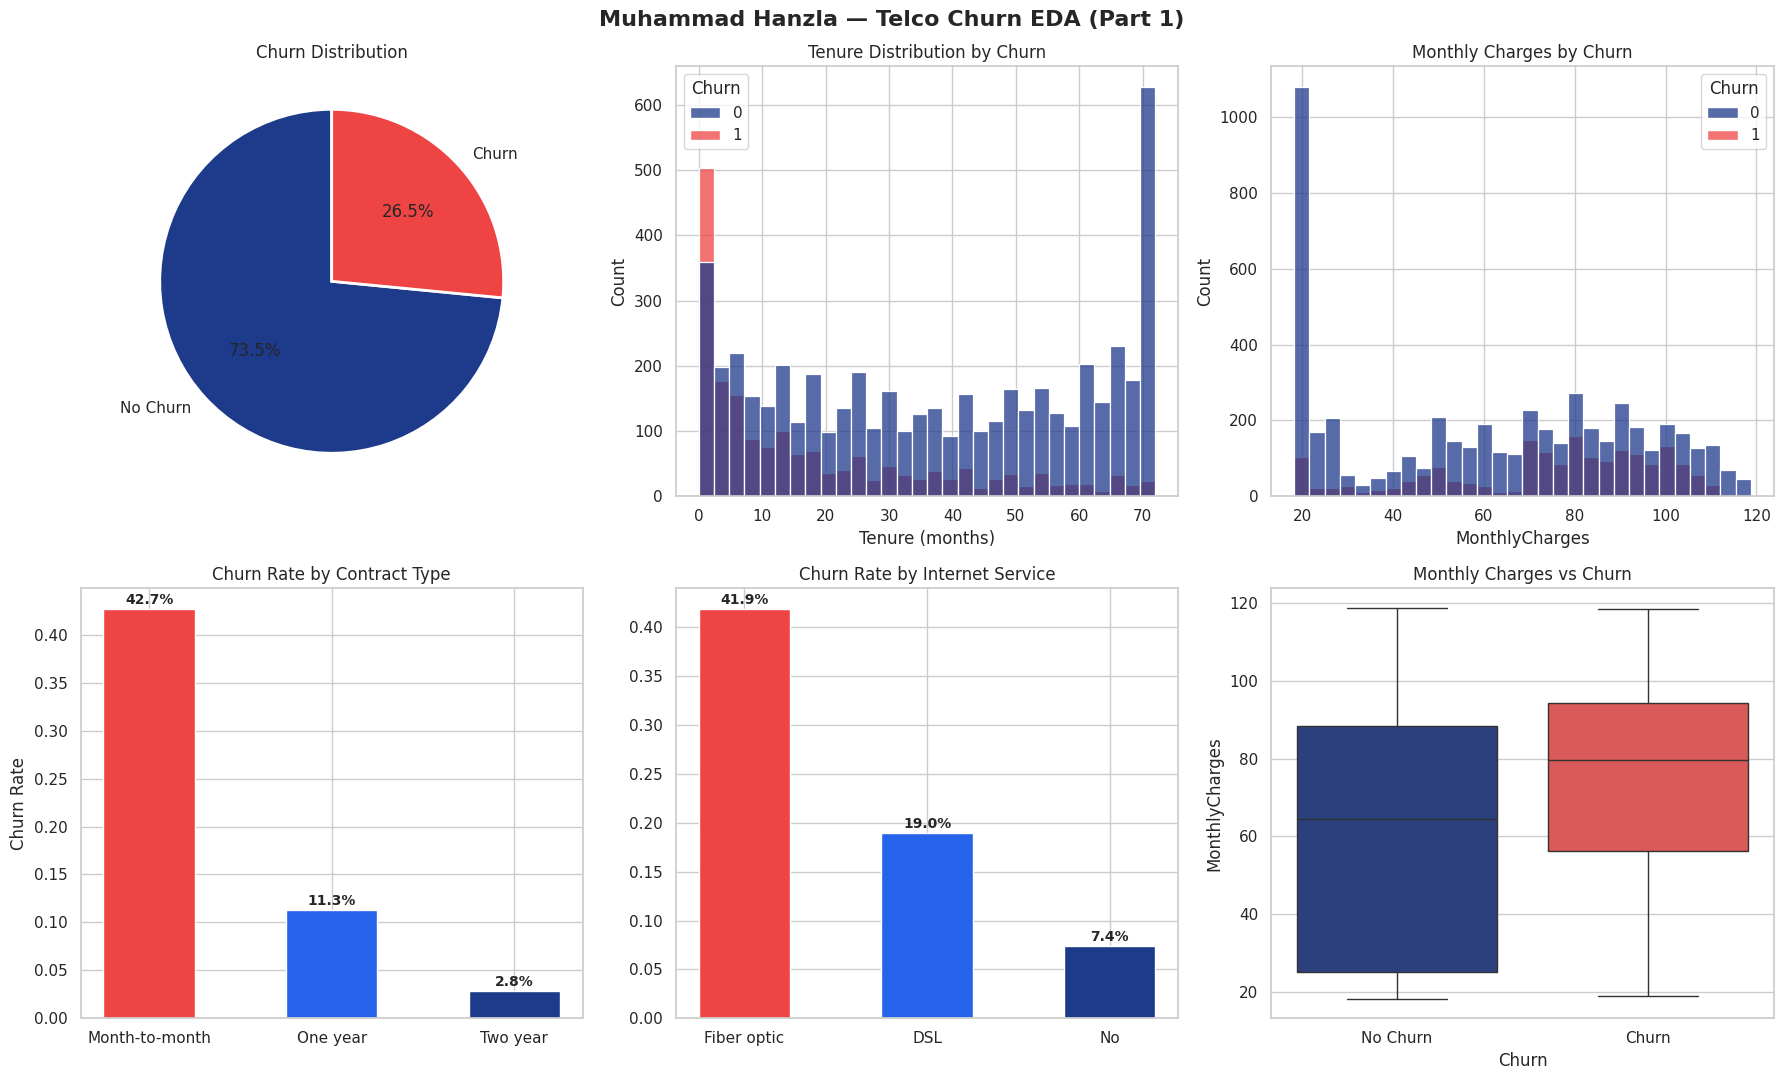

EDA Part 1 saved ✅


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Muhammad Hanzla — Telco Churn EDA (Part 1)', fontsize=16, fontweight='bold')

# Churn distribution
counts = df['Churn'].value_counts()
axes[0,0].pie(counts, labels=['No Churn','Churn'], autopct='%1.1f%%',
              colors=['#1e3a8a','#ef4444'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Churn Distribution')

# Tenure histogram
sns.histplot(data=df, x='tenure', hue='Churn', ax=axes[0,1],
             palette={0:'#1e3a8a',1:'#ef4444'}, bins=30, alpha=0.75)
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Tenure (months)')

# Monthly charges
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[0,2],
             palette={0:'#1e3a8a',1:'#ef4444'}, bins=30, alpha=0.75)
axes[0,2].set_title('Monthly Charges by Churn')

# Contract type churn rate
ct = df.groupby('Contract')['Churn'].mean().reset_index().sort_values('Churn', ascending=False)
bars = axes[1,0].bar(ct['Contract'], ct['Churn'], color=['#ef4444','#2563eb','#1e3a8a'],
                      edgecolor='white', width=0.5)
axes[1,0].set_title('Churn Rate by Contract Type')
axes[1,0].set_ylabel('Churn Rate')
for bar, val in zip(bars, ct['Churn']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

# Internet service churn rate
it = df.groupby('InternetService')['Churn'].mean().reset_index().sort_values('Churn', ascending=False)
bars2 = axes[1,1].bar(it['InternetService'], it['Churn'],
                       color=['#ef4444','#2563eb','#1e3a8a'], edgecolor='white', width=0.5)
axes[1,1].set_title('Churn Rate by Internet Service')
for bar, val in zip(bars2, it['Churn']):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

# Monthly charges boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1,2],
            palette={"0":'#1e3a8a',"1":'#ef4444'})
axes[1,2].set_title('Monthly Charges vs Churn')
axes[1,2].set_xticklabels(['No Churn','Churn'])

plt.tight_layout()
plt.savefig('01_eda_part1.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA Part 1 saved ✅')

### 4.2 Service Features & Correlation

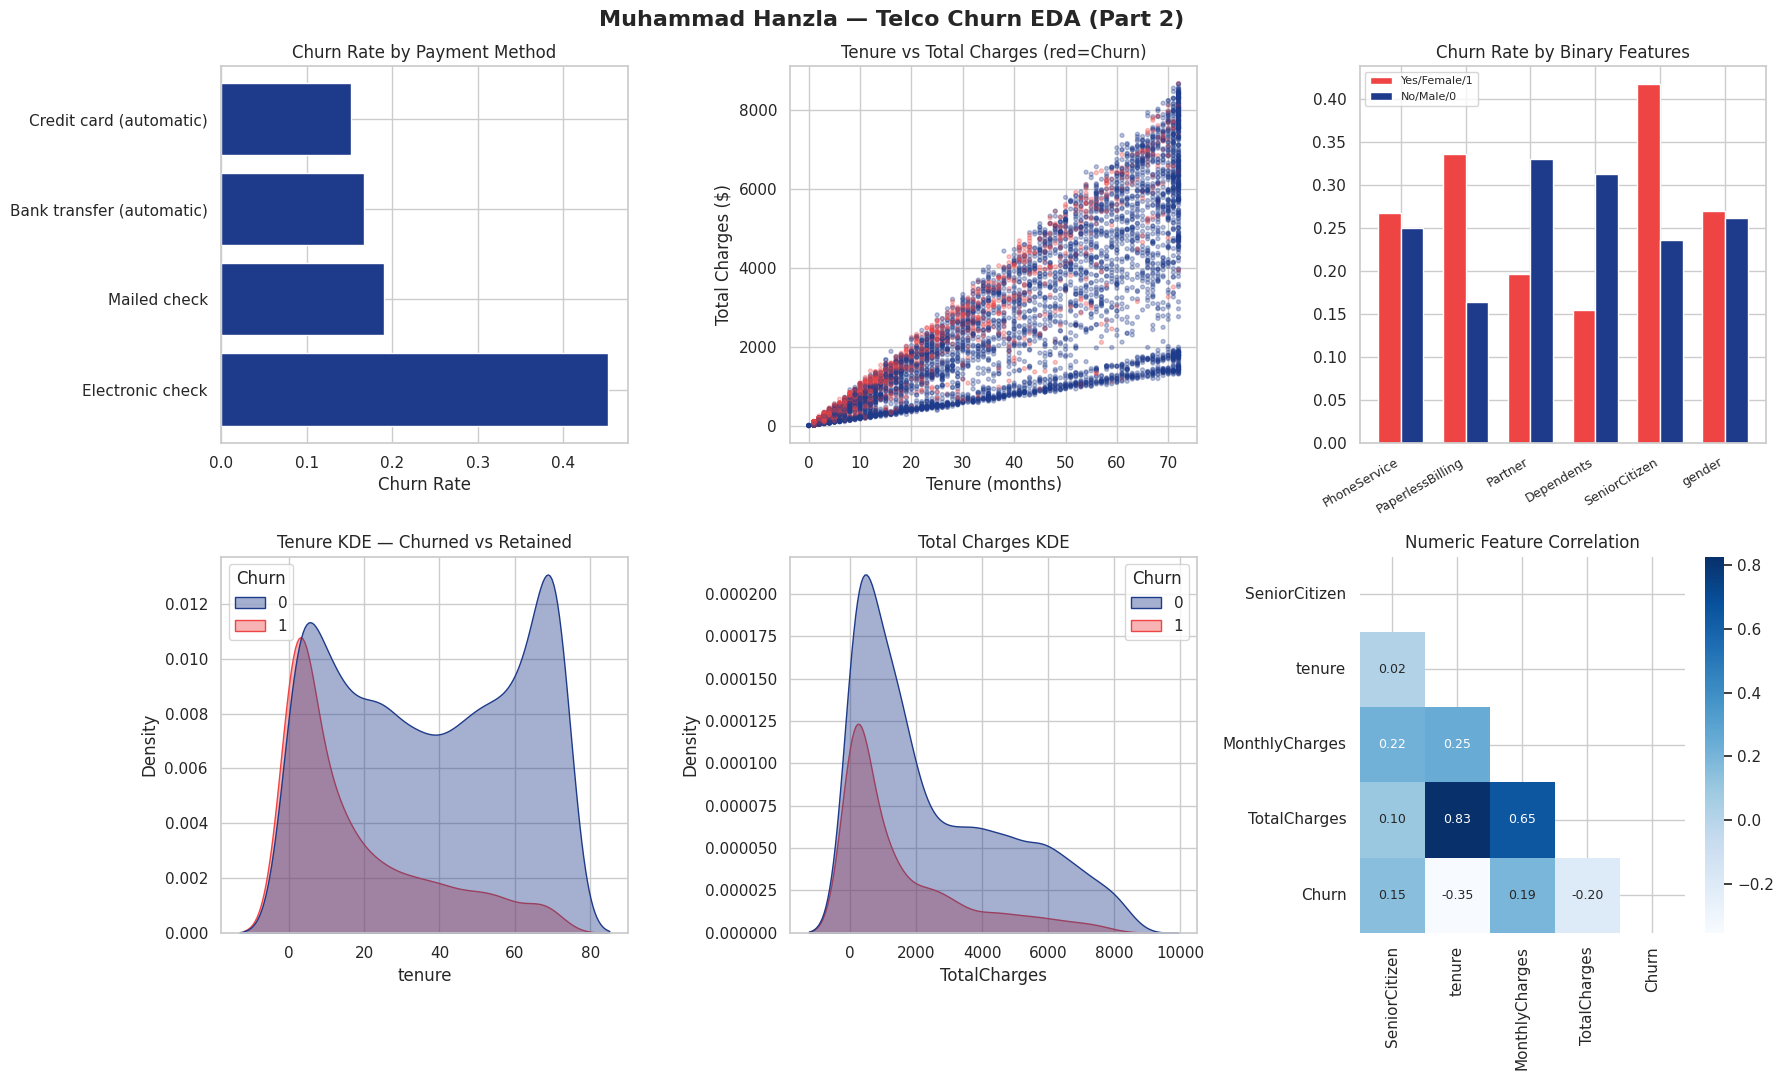

EDA Part 2 saved ✅


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Muhammad Hanzla — Telco Churn EDA (Part 2)', fontsize=16, fontweight='bold')

# Payment method
pm = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
axes[0,0].barh(pm.index, pm.values, color='#1e3a8a', edgecolor='white')
axes[0,0].set_title('Churn Rate by Payment Method')
axes[0,0].set_xlabel('Churn Rate')

# TotalCharges vs tenure coloured by churn
scatter_colors = df['Churn'].map({0:'#1e3a8a', 1:'#ef4444'})
axes[0,1].scatter(df['tenure'], df['TotalCharges'], c=scatter_colors,
                   alpha=0.3, s=8)
axes[0,1].set_xlabel('Tenure (months)'); axes[0,1].set_ylabel('Total Charges ($)')
axes[0,1].set_title('Tenure vs Total Charges (red=Churn)')

# Multiple binary features churn rates
binary_cols = ['PhoneService','PaperlessBilling','Partner','Dependents',
               'SeniorCitizen','gender']
# Map gender
df_temp = df.copy()
df_temp['gender'] = (df_temp['gender'] == 'Female').astype(int)
for col in ['PhoneService','PaperlessBilling','Partner','Dependents']:
    if df_temp[col].dtype == object:
        df_temp[col] = (df_temp[col] == 'Yes').astype(int)
churn_by_feature = {col: df_temp.groupby(col)['Churn'].mean() for col in binary_cols}
churn_yes = [churn_by_feature[c].get(1, 0) for c in binary_cols]
churn_no  = [churn_by_feature[c].get(0, 0) for c in binary_cols]
x = np.arange(len(binary_cols)); w = 0.35
axes[0,2].bar(x - w/2, churn_yes, w, label='Yes/Female/1', color='#ef4444', edgecolor='white')
axes[0,2].bar(x + w/2, churn_no,  w, label='No/Male/0',   color='#1e3a8a', edgecolor='white')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(binary_cols, rotation=30, ha='right', fontsize=9)
axes[0,2].set_title('Churn Rate by Binary Features'); axes[0,2].legend(fontsize=8)

# Tenure distribution
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True,
            palette={0:'#1e3a8a',1:'#ef4444'}, alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('Tenure KDE — Churned vs Retained')

# TotalCharges distribution
sns.kdeplot(data=df[df['TotalCharges']>0], x='TotalCharges',
            hue='Churn', fill=True,
            palette={0:'#1e3a8a',1:'#ef4444'}, alpha=0.4, ax=axes[1,1])
axes[1,1].set_title('Total Charges KDE')

# Numeric correlation heatmap
num_df = df.select_dtypes(include=np.number)
corr   = num_df.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f',
            cmap='Blues', mask=mask, annot_kws={'size':9})
axes[1,2].set_title('Numeric Feature Correlation')

plt.tight_layout()
plt.savefig('02_eda_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA Part 2 saved ✅')

## 5. Preprocessing & Feature Engineering

In [7]:
# ── Encode all categorical columns ──────────────────────

df_model = df.copy()

# Binary Yes/No columns → 0/1
yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']
for col in yes_no_cols:
    df_model[col] = (df_model[col] == 'Yes').astype(int)

# gender
df_model['gender'] = (df_model['gender'] == 'Female').astype(int)

# Multi-class categoricals → Label Encode
multi_cols = ['MultipleLines','InternetService','OnlineSecurity',
              'OnlineBackup','DeviceProtection','TechSupport',
              'StreamingTV','StreamingMovies','Contract','PaymentMethod']
le = LabelEncoder()
for col in multi_cols:
    df_model[col] = le.fit_transform(df_model[col])

# ── Feature Engineering ──────────────────────────────────
df_model['AvgMonthlySpend']    = df_model['TotalCharges'] / (df_model['tenure'] + 1)
df_model['IsHighValue']        = (df_model['MonthlyCharges'] > df_model['MonthlyCharges'].quantile(0.75)).astype(int)
df_model['IsLongTermCustomer'] = (df_model['tenure'] > 24).astype(int)
df_model['IsNewCustomer']      = (df_model['tenure'] <= 6).astype(int)
df_model['ChargesPerTenure']   = df_model['MonthlyCharges'] / (df_model['tenure'] + 1)
df_model['HasStreaming']       = ((df_model['StreamingTV'] > 0) | (df_model['StreamingMovies'] > 0)).astype(int)
df_model['HasOnlineServices']  = ((df_model['OnlineSecurity'] > 0) | (df_model['OnlineBackup'] > 0)).astype(int)
df_model['ServiceCount']       = (df_model[['OnlineSecurity','OnlineBackup',
                                              'DeviceProtection','TechSupport',
                                              'StreamingTV','StreamingMovies']] > 0).sum(axis=1)

print(f'Total features after engineering : {df_model.shape[1] - 1}')
print(df_model.dtypes)
df_model.head(3)

Total features after engineering : 27
gender                  int64
SeniorCitizen           int64
Partner                 int64
Dependents              int64
tenure                  int64
PhoneService            int64
MultipleLines           int64
InternetService         int64
OnlineSecurity          int64
OnlineBackup            int64
DeviceProtection        int64
TechSupport             int64
StreamingTV             int64
StreamingMovies         int64
Contract                int64
PaperlessBilling        int64
PaymentMethod           int64
MonthlyCharges        float64
TotalCharges          float64
Churn                   int64
AvgMonthlySpend       float64
IsHighValue             int64
IsLongTermCustomer      int64
IsNewCustomer           int64
ChargesPerTenure      float64
HasStreaming            int64
HasOnlineServices       int64
ServiceCount            int64
dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,AvgMonthlySpend,IsHighValue,IsLongTermCustomer,IsNewCustomer,ChargesPerTenure,HasStreaming,HasOnlineServices,ServiceCount
0,1,0,1,0,1,0,1,0,0,2,...,29.85,0,14.925000,0,0,1,14.925000,0,1,1
1,0,0,0,0,34,1,0,0,2,0,...,1889.50,0,53.985714,0,1,0,1.627143,0,1,2
2,0,0,0,0,2,1,0,0,2,2,...,108.15,1,36.050000,0,0,1,17.950000,0,1,2


## 6. Handle Class Imbalance with SMOTE

In [8]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Scale features
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'Original → Churn: {y.sum():,} ({y.mean():.2%}) | No Churn: {(y==0).sum():,}')

# SMOTE oversampling on training data only
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

sm = SMOTE(random_state=42, k_neighbors=5)
X_train, y_train = sm.fit_resample(X_train_raw, y_train_raw)

print(f'After SMOTE → Train Churn: {y_train.sum():,} | Train No Churn: {(y_train==0).sum():,}')
print(f'Test set (no SMOTE) → Churn: {y_test.sum():,} | No Churn: {(y_test==0).sum():,}')
print(f'\nTrain size : {X_train.shape[0]:,}')
print(f'Test  size : {X_test.shape[0]:,}')

Original → Churn: 1,869 (26.54%) | No Churn: 5,174
After SMOTE → Train Churn: 4,139 | Train No Churn: 4,139
Test set (no SMOTE) → Churn: 374 | No Churn: 1,035

Train size : 8,278
Test  size : 1,409


## 7. Model Comparison

In [9]:
from sklearn.metrics import f1_score, accuracy_score

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                                        learning_rate=0.05,
                                                        subsample=0.8, random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('─' * 60)
print(f'{"Model":<25} {"CV AUC":>10} {"CV F1":>10}')
print('─' * 60)

for name, m in models.items():
    m.fit(X_train, y_train)
    cv_auc = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    cv_f1  = cross_val_score(m, X_train, y_train, cv=cv, scoring='f1').mean()
    results[name] = {'model': m, 'cv_auc': cv_auc, 'cv_f1': cv_f1}
    print(f'{name:<25} {cv_auc:>10.4f} {cv_f1:>10.4f}')

print('─' * 60)
best_name  = max(results, key=lambda k: results[k]['cv_auc'])
best_model = results[best_name]['model']
print(f'\n🏆 Best Model : {best_name}')

────────────────────────────────────────────────────────────
Model                         CV AUC      CV F1
────────────────────────────────────────────────────────────
Logistic Regression           0.8527     0.7797
Random Forest                 0.9305     0.8607
Gradient Boosting             0.9378     0.8606
────────────────────────────────────────────────────────────

🏆 Best Model : Gradient Boosting


## 8. Final Model Evaluation

In [10]:
# Evaluate best model on test set
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)

print(f'Test AUC-ROC           : {auc:.4f}')
print(f'Average Precision (AP) : {ap:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

Test AUC-ROC           : 0.8356
Average Precision (AP) : 0.6439

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.59      0.60      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



## 9. Result Visualizations

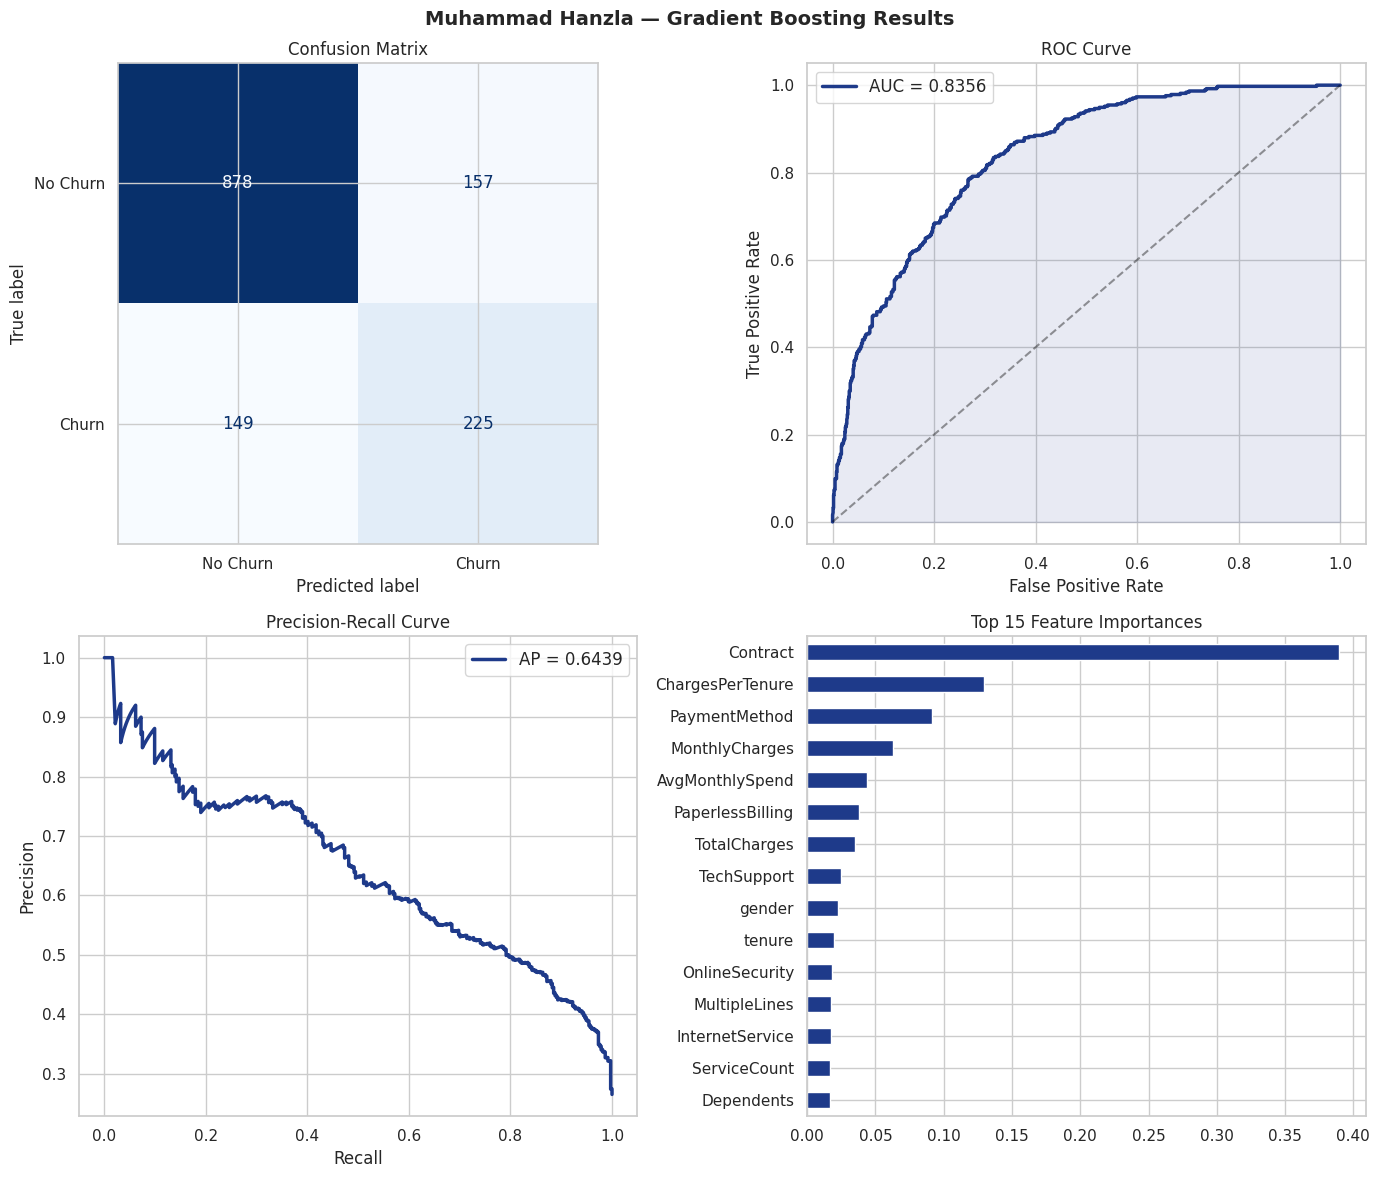

Results saved → 03_model_results.png ✅


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'Muhammad Hanzla — {best_name} Results', fontsize=14, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0,0], colorbar=False, cmap='Blues',
    display_labels=['No Churn','Churn'])
axes[0,0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0,1].plot(fpr, tpr, color='#1e3a8a', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0,1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#1e3a8a')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(fontsize=12)

# Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
axes[1,0].plot(recalls, precisions, color='#1e3a8a', lw=2.5, label=f'AP = {ap:.4f}')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].legend(fontsize=12)

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    feat_imp.plot.barh(ax=axes[1,1], color='#1e3a8a', edgecolor='white')
    axes[1,1].set_title('Top 15 Feature Importances')
else:
    coef = pd.Series(abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=True).tail(15)
    coef.plot.barh(ax=axes[1,1], color='#1e3a8a', edgecolor='white')
    axes[1,1].set_title('Top 15 Feature Coefficients (abs)')

plt.tight_layout()
plt.savefig('03_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Results saved → 03_model_results.png ✅')

## 10. Business-Aware Threshold Tuning
Default threshold = 0.5 misses many churners. We tune it to maximise **F1-score** (balances precision and recall).

Default  threshold (0.50) → F1 = 0.5952
Optimised threshold (0.30) → F1 = 0.6214


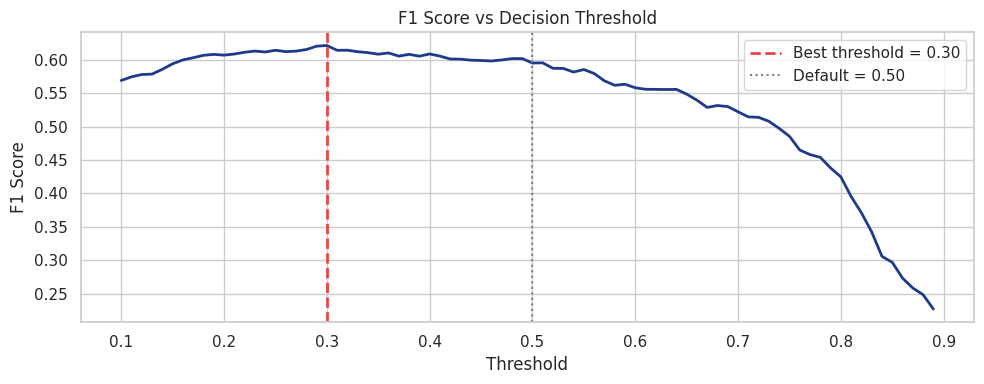


Classification Report (optimised threshold):
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [12]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f'Default  threshold (0.50) → F1 = {f1_score(y_test, (y_proba>=0.50).astype(int)):.4f}')
print(f'Optimised threshold ({best_thresh:.2f}) → F1 = {best_f1:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color='#1e3a8a', lw=2)
ax.axvline(best_thresh, color='#ef4444', ls='--', lw=2, label=f'Best threshold = {best_thresh:.2f}')
ax.axvline(0.50, color='gray', ls=':', lw=1.5, label='Default = 0.50')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Decision Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('04_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_tuned = (y_proba >= best_thresh).astype(int)
print('\nClassification Report (optimised threshold):')
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn','Churn']))

## 11. Save Model & Scaler

In [13]:
import pickle

with open('churn_model.pkl',  'wb') as f: pickle.dump(best_model, f)
with open('churn_scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('feature_names.pkl','wb') as f: pickle.dump(list(X.columns), f)

print('✅ Saved:')
print('   churn_model.pkl   — trained model')
print('   churn_scaler.pkl  — fitted StandardScaler')
print('   feature_names.pkl — list of feature names')

✅ Saved:
   churn_model.pkl   — trained model
   churn_scaler.pkl  — fitted StandardScaler
   feature_names.pkl — list of feature names


## 12. Flask REST API
Run this file independently as `app.py` → test with Postman or curl.

In [14]:
flask_code = '''
# app.py — Customer Churn Prediction REST API
# Author : Muhammad Hanzla
# Run    : python app.py
# Test   : POST http://localhost:5000/predict

from flask import Flask, request, jsonify
import numpy as np, pickle

app = Flask(__name__)

model         = pickle.load(open("churn_model.pkl",   "rb"))
scaler        = pickle.load(open("churn_scaler.pkl",  "rb"))
feature_names = pickle.load(open("feature_names.pkl", "rb"))

@app.route("/", methods=["GET"])
def home():
    return jsonify({"message": "Churn Prediction API — Muhammad Hanzla",
                    "status" : "running",
                    "features": feature_names})

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data      = request.get_json(force=True)
        row       = [data[f] for f in feature_names]
        row_arr   = np.array(row).reshape(1, -1)
        row_scaled= scaler.transform(row_arr)
        pred      = model.predict(row_scaled)[0]
        prob      = model.predict_proba(row_scaled)[0][1]
        return jsonify({
            "churn"      : bool(pred),
            "probability": round(float(prob), 4),
            "risk_level" : "High" if prob > 0.70 else "Medium" if prob > 0.40 else "Low"
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 400

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=True)
'''
with open('app.py', 'w') as f:
    f.write(flask_code)
print('Flask API saved → app.py ✅')
print()
print('='*50)
print('✅ PROJECT  COMPLETE — Muhammad Hanzla')
print('='*50)
print(f'  Dataset   : Real Telco Customer Churn (Kaggle)')
print(f'  Best model: {best_name}')
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Avg Prec  : {ap:.4f}')
print(f'  Outputs   : 4 PNG plots + model.pkl + app.py')

Flask API saved → app.py ✅

✅ PROJECT  COMPLETE — Muhammad Hanzla
  Dataset   : Real Telco Customer Churn (Kaggle)
  Best model: Gradient Boosting
  AUC-ROC   : 0.8356
  Avg Prec  : 0.6439
  Outputs   : 4 PNG plots + model.pkl + app.py




<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 30px; border-radius: 12px; text-align: center;">
<h3 style="color: #60a5fa;">Connect with Muhammad Hanzla</h3>
<p style="color: #94a3b8;">Feel free to reach out for collaboration, feedback, or opportunities!</p>
<div style="margin-top: 15px;">
<a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; margin: 0 15px;'>📧 Email</a>
<a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; margin: 0 15px;'>📊 Kaggle</a>
<a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; margin: 0 15px;'>💻 GitHub</a>
<a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; margin: 0 15px;'>💼 LinkedIn</a>
<a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; margin: 0 15px;'>📷 Instagram</a>
</div>
</div>